In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def thomas_algorithm(a, b, c, d):
    n = len(b)

    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [5]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # h_i = x_{i+1} - x_i
 
    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)
 
    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])
 
    return A, B, C, D

In [6]:
def compute_second_derivatives(x, y):
    n = len(x)
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    M_interior = thomas_algorithm(A, B, C, D)
    M = np.zeros(n)
    M[1:-1] = M_interior
    return M

In [7]:
def evaluate_spline(x, y, M, x_eval):
    h      = np.diff(x)
    y_eval = np.zeros_like(x_eval, dtype=float)
    for j, xval in enumerate(x_eval):
        i        = int(np.clip(np.searchsorted(x, xval, side='right') - 1, 0, len(x) - 2))
        hi       = h[i]
        dx_right = x[i + 1] - xval
        dx_left  = xval - x[i]
        term1 = M[i]     / (6 * hi) * dx_right**3
        term2 = M[i + 1] / (6 * hi) * dx_left**3
        term3 = (y[i]     / hi - M[i]     * hi / 6) * dx_right
        term4 = (y[i + 1] / hi - M[i + 1] * hi / 6) * dx_left
        y_eval[j] = term1 + term2 + term3 + term4
    return y_eval

In [9]:
def cubic_spline_interpolation(x_data, y_data, step=0.01):
    x = np.array(x_data, dtype=float)
    y = np.array(y_data, dtype=float)
 
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    print("Subdiagonal  (A):", A)
    print("Main diagonal(B):", B)
    print("Superdiagonal(C):", C)
    print("Right-hand   (D):", D)
 
    M = compute_second_derivatives(x, y)
    print("\nSecond derivatives M:", M)
 

    x_fine = np.arange(x[0], x[-1] + step, step)
    y_fine = evaluate_spline(x, y, M, x_fine)
 
    plt.figure(figsize=(9, 5))
    plt.plot(x_fine, y_fine, linewidth=2, label='Cubic Spline')
    plt.scatter(x, y, color='crimson', zorder=5, s=70, label='Data Points')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Subdiagonal (A): [1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1.]
Right-hand side (D): [-12.  12. -12.  12.]
[ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]


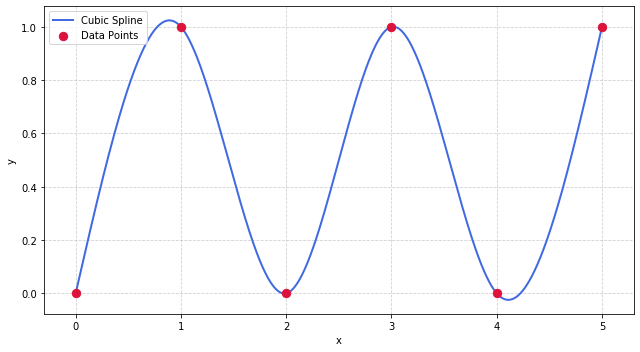

In [12]:
if __name__ == "__main__":
 

    x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
    y = np.array([0, 1, 0, 1, 0, 1], dtype=float)
 

    A, B, C, D = setup_tridiagonal_matrix(x, y)
    print("Subdiagonal (A):", A)
    print("Main diagonal (B):", B)
    print("Superdiagonal (C):", C)
    print("Right-hand side (D):", D)
 

    M = thomas_algorithm(A, B, C, D)
    M = np.insert(M, 0, 0)
    M = np.append(M, 0)
    print(M)
 
    # Evaluate and plot
    xeval = np.linspace(0, 5, 1000)
    yeval = evaluate_spline(x, y, M, xeval)
 
    yeval = yeval[0:len(yeval)-1]
    xeval = xeval[0:len(xeval)-1]
 
    plt.figure(figsize=(9, 5))
    plt.plot(xeval, yeval, color='royalblue', linewidth=2, label='Cubic Spline')
    plt.scatter(x, y, color='crimson', zorder=5, s=70, label='Data Points')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()